## Import Packages And Define Functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

#### Import TALib Only If Necessary

In [ ]:
url = 'https://anaconda.org/conda-forge/libta-lib/0.4.0/download/linux-64/libta-lib-0.4.0-h166bdaf_1.tar.bz2'
!curl -L $url | tar xj -C /usr/lib/x86_64-linux-gnu/ lib --strip-components=1
url = 'https://anaconda.org/conda-forge/ta-lib/0.4.19/download/linux-64/ta-lib-0.4.19-py310hde88566_4.tar.bz2'
!curl -L $url | tar xj -C /usr/local/lib/python3.10/dist-packages/ lib/python3.10/site-packages/talib --strip-components=3
import talib

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4420    0  4420    0     0  20896      0 --:--:-- --:--:-- --:--:-- 20947
100  517k  100  517k    0     0  1153k      0 --:--:-- --:--:-- --:--:-- 1153k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4384    0  4384    0     0  20517      0 --:--:-- --:--:-- --:--:-- 20582
100  392k  100  392k    0     0   804k      0 --:--:-- --:--:-- --:--:--  804k


In [ ]:
def annual_num_transaction(position):
    return sum(np.where(position != position.shift(1), 1, 0)) / len(position) * 252.

def annual_return(returns):
    return returns.mean() * 252.

def annual_volatility(returns):
    return returns.std() * (252. ** 0.5)

def cum_return(returns):
    return list(np.exp(returns.cumsum()))[-1]

def max_drawdown(returns):
    cum_returns = np.exp(returns.cumsum())
    cum_max = cum_returns.cummax()
    return ((cum_max - cum_returns) / cum_max).max()

def information_ratio(strategy_return, benchmark_return):
    track_error = annual_volatility(strategy_return - benchmark_return)
    if track_error < 1e-9:
        return 0.
    else:
        return (annual_return(strategy_return) - annual_return(benchmark_return)) / track_error

## Data Cleaning

In [ ]:
!pip install yfinance
import yfinance as yf

In [ ]:
code = [
    "^GSPC",
    "AAPL",
    "JPM",
    "GOOGL",
    "000300.SS", #HS300
    "600887.SS", #YLGF
    "600519.SS", #GZMT
    "600897.SS", #XMKG
    "601601.SS", #ZGTB
    "600188.SS", #YKNY
    "601318.SS", #ZGPA
    "600900.SS", #CJDL
    "600000.SS", #PFYH
    "002460.SZ", #GFLY
]
data_train = yf.download("^GSPC", start = "2007-01-01", end = "2023-01-01", auto_adjust = False)
data_train["close"] = data_train["Adj Close"]
data_train["open"] = data_train["Open"]
data_train["high"] = data_train["High"]
data_train["low"] = data_train["Low"]
data_train["return"] = np.log(data_train["close"] / data_train["close"].shift(1))
data_test = yf.download("^GSPC", start = "2022-01-01", auto_adjust = False)
data_test["close"] = data_test["Adj Close"]
data_test["open"] = data_test["Open"]
data_test["high"] = data_test["High"]
data_test["low"] = data_test["Low"]
data_test["return"] = np.log(data_test["close"] / data_test["close"].shift(1))

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


## Strategy

In [ ]:
windows = [5, 14, 30, 60, 120]
up_thresholds = [60, 70, 80]
down_thresholds = [10, 20, 30]
up_stds = [0., 0.5, 1.]
down_stds = [0., 0.5, 1.]
transaction_cost = 0.
# max history data needed
look_back_window = 365
# backtest for 24 months
backtest_length = 365 * 2
backtest_launch_points = [
    "2007-12-31",
    "2009-12-31",
    "2011-12-31",
    "2013-12-31",
    "2016-12-31",
    "2019-12-31",
    "2021-12-31",
    ]
performance = pd.DataFrame(columns = ["window",
                                      "up_threshold",
                                      "down_threshold",
                                      "up_std",
                                      "down_std",
                                      "launch_point",
                                      "num_transaction_per_year",
                                      "annual_return",
                                      "annual_vol",
                                      "cum_return",
                                      "max_drawdown",
                                      "information_ratio"
                                      ])
for launch_point in backtest_launch_points:
    new_row = pd.DataFrame({
        "window": 0,
        "up_threshold": 0,
        "down_threshold": 0,
        "up_std": 0,
        "down_std": 0,
        "launch_point": launch_point,
        "num_transaction_per_year": 0,
        "annual_return": annual_return(data_train[pd.to_datetime(launch_point):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]["return"]),
        "annual_vol": annual_volatility(data_train[pd.to_datetime(launch_point):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]["return"]),
        "cum_return": cum_return(data_train[pd.to_datetime(launch_point):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]["return"]),
        "max_drawdown": max_drawdown(data_train[pd.to_datetime(launch_point):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]["return"]),
        "information_ratio": 0
        }, index = [0])
    performance = pd.concat([performance, new_row], ignore_index = True)

In [ ]:
def RSI(window, up_threshold, down_threshold, up_std, down_std, df, launch_point, look_back_window, backtest_length, launch_position):
    dataframe = df.copy(deep = True)
    dataframe = dataframe[(pd.to_datetime(launch_point) - pd.to_timedelta(look_back_window, unit = "d")):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]
    dataframe[f"position_strategy"] = launch_position
    dataframe[f"price_change"] = dataframe[f"close"].diff()
    avg_up = dataframe[f"price_change"].where(dataframe[f"price_change"] > 0., 0.).rolling(window).mean()
    avg_down = dataframe[f"price_change"].where(dataframe[f"price_change"] < 0., 0.).rolling(window).mean().abs()
    dataframe[f"RS"] = avg_up / avg_down
    dataframe[f"RSI"] = 100. - 100. / (1. + dataframe[f"RS"])
    dataframe[f"RSI_std"] = dataframe[f"RSI"].rolling(window).std()
    # set index to be 0, 1, 2, ...
    dataframe["date"] = dataframe.index
    dataframe.index = range(len(dataframe))
    # for static stop loss
    open_price = 0.
    # when launch point is not a business day
    while len(dataframe[dataframe["date"] == launch_point].index.values) == 0:
        launch_point = str(pd.to_datetime(launch_point) + pd.to_timedelta(1, unit = "d"))
    launch_point_index = dataframe[dataframe["date"] == launch_point].index.values[0]
    # add extra row for forecast purpose
    last_date = pd.to_datetime(dataframe.loc[len(dataframe) - 1, "date"])
    dataframe.loc[len(dataframe), "date"] = last_date + pd.to_timedelta(1, unit = "d")
    # strategy logic
    for i in range(launch_point_index + 1, len(dataframe)):
        if dataframe.loc[i - 1, f"position_strategy"] == 0:
            if dataframe.loc[i - 1, f"RSI"] < down_threshold - down_std * dataframe.loc[i - 1, f"RSI_std"]:
                dataframe.loc[i, f"position_strategy"] = 1
                open_price = dataframe.loc[i, "open"]
            else:
                dataframe.loc[i, f"position_strategy"] = dataframe.loc[i - 1, f"position_strategy"]
        else:
            if (dataframe.loc[i - 1, f"RSI"] > up_threshold + up_std * dataframe.loc[i - 1, f"RSI_std"])\
            | (((dataframe.loc[i - 1, f"close"] -  dataframe.loc[i - 2, f"close"]) / dataframe.loc[i - 2, f"close"]) < -0.05)\
            | (((dataframe.loc[i - 1, f"close"] -  dataframe.loc[i - 6, f"close"]) / dataframe.loc[i - 6, f"close"]) < -0.3):
                dataframe.loc[i, f"position_strategy"] = 0
                open_price = 0.
            else:
                dataframe.loc[i, f"position_strategy"] = dataframe.loc[i - 1, f"position_strategy"]
    dataframe[f"return_strategy"] = dataframe[f"position_strategy"] * dataframe["return"]
    # set index back to date
    dataframe.set_index("date", inplace = True)
    dataframe_drop = dataframe[(pd.to_datetime(launch_point) + pd.to_timedelta(1, unit = "d")):(pd.to_datetime(launch_point) + pd.to_timedelta(backtest_length, unit = "d"))]
    return dataframe_drop

## Train

In [ ]:
for window in windows:
    for up_threshold in up_thresholds:
        for down_threshold in down_thresholds:
            for up_std in up_stds:
                for down_std in down_stds:
                    for launch_point in backtest_launch_points:
                        output_train = RSI(window, up_threshold, down_threshold, up_std, down_std, data_train, launch_point, look_back_window, backtest_length, 0)
                        # drop the added last row
                        output_train = output_train.dropna()
                        new_row = pd.DataFrame({
                            "window": window,
                            "up_threshold": up_threshold,
                            "down_threshold": down_threshold,
                            "up_std": up_std,
                            "down_std": down_std,
                            "launch_point": launch_point,
                            "num_transaction_per_year": annual_num_transaction(output_train[f"position_strategy"]),
                            "annual_return": annual_return(output_train[f"return_strategy"]),
                            "annual_vol": annual_volatility(output_train[f"return_strategy"]),
                            "cum_return": cum_return(output_train[f"return_strategy"]),
                            "max_drawdown": max_drawdown(output_train[f"return_strategy"]),
                            "information_ratio": information_ratio(output_train[f"return_strategy"], output_train["return"])
                        }, index = [0])
                        performance = pd.concat([performance, new_row], ignore_index = True)

In [ ]:
# calculate average information ration through all bt launch points
tmp = pd.DataFrame(columns = ["window",
                              "up_threshold",
                              "down_threshold",
                              "up_std",
                              "down_std",
                              "avg_information_ratio"
                              ])
for window in windows:
    for up_threshold in up_thresholds:
        for down_threshold in down_thresholds:
            for up_std in up_stds:
                for down_std in down_stds:
                    new_row = pd.DataFrame({
                        "window": window,
                        "up_threshold": up_threshold,
                        "down_threshold": down_threshold,
                        "up_std": up_std,
                        "down_std": down_std,
                        "avg_information_ratio": performance[(performance["window"] == window) &
                        (performance["up_threshold"] == up_threshold) &
                        (performance["down_threshold"] == down_threshold) &
                        (performance["up_std"] == up_std) &
                        (performance["down_std"] == down_std)][["information_ratio"]].mean().values[0]
                        }, index = [0])
                    tmp = pd.concat([tmp, new_row], ignore_index = True)
performance = pd.merge(performance, tmp, on = ["window", "up_threshold", "down_threshold", "up_std", "down_std"], how = "left")

In [ ]:
performance.sort_values(by = ["avg_information_ratio", "window", "up_threshold", "down_threshold", "up_std", "down_std", "launch_point"], ascending = False)

,window,up_threshold,down_threshold,up_std,down_std,launch_point,num_transaction_per_year,annual_return,annual_vol,cum_return,max_drawdown,information_ratio,avg_information_ratio
482,5,80,20,0.5,0.5,2021-12-31,8.031873,-0.077254,0.230485,0.925939,0.215291,1.887903,0.240519
481,5,80,20,0.5,0.5,2019-12-31,5.5,-0.019386,0.107024,0.961970,0.162728,-0.898123,0.240519
480,5,80,20,0.5,0.5,2016-12-31,12.071856,0.057642,0.102893,1.121422,0.113151,0.063265,0.240519
479,5,80,20,0.5,0.5,2013-12-31,11.0,0.122561,0.101789,1.277778,0.114302,0.805522,0.240519
478,5,80,20,0.5,0.5,2011-12-31,9.576,0.074296,0.071443,1.158832,0.073639,-1.150418,0.240519
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0,0,0,0,0,2016-12-31,0,0.056762,0.129921,1.119714,0.197782,0,NaN
3,0,0,0,0,0,2013-12-31,0,0.052163,0.135836,1.110191,0.123525,0,NaN
2,0,0,0,0,0,2011-12-31,0,0.191712,0.119461,1.463955,0.099363,0,NaN
1,0,0,0,0,0,2009-12-31,0,0.054971,0.208512,1.116457,0.193882,0,NaN


## Backtest

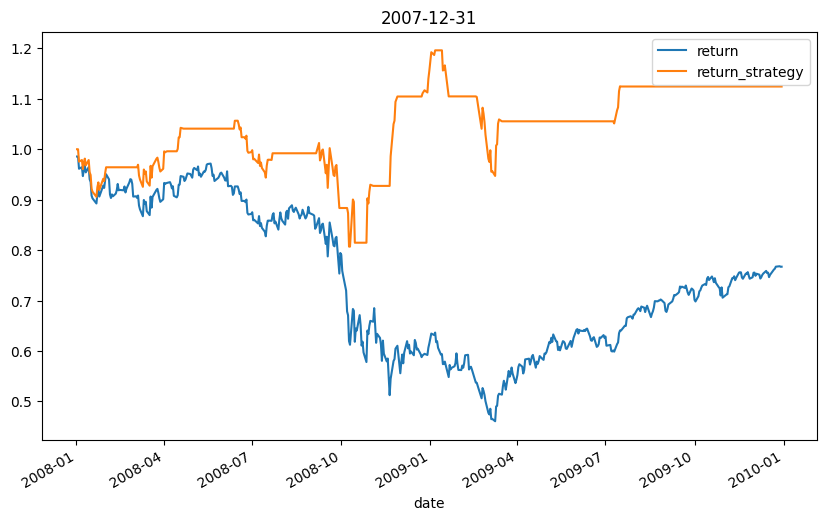

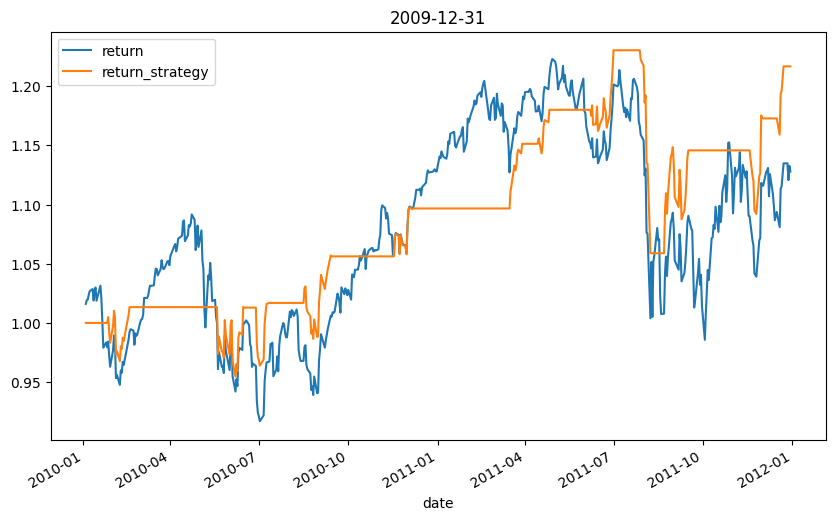

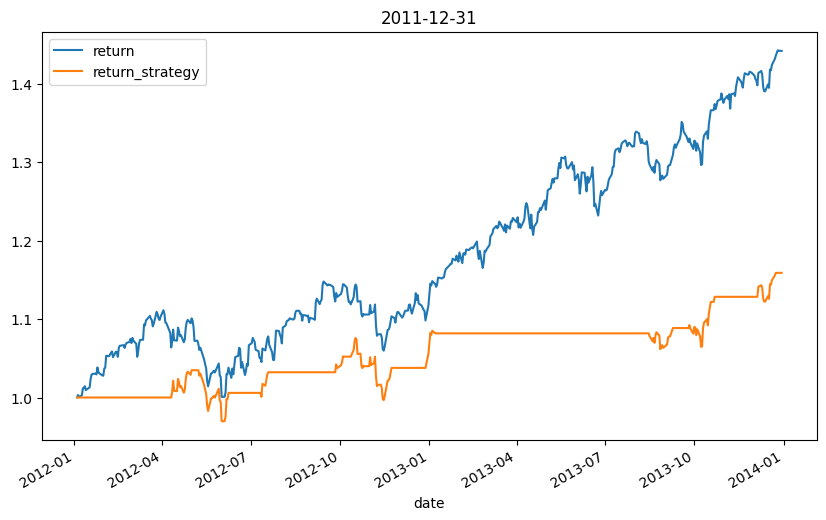

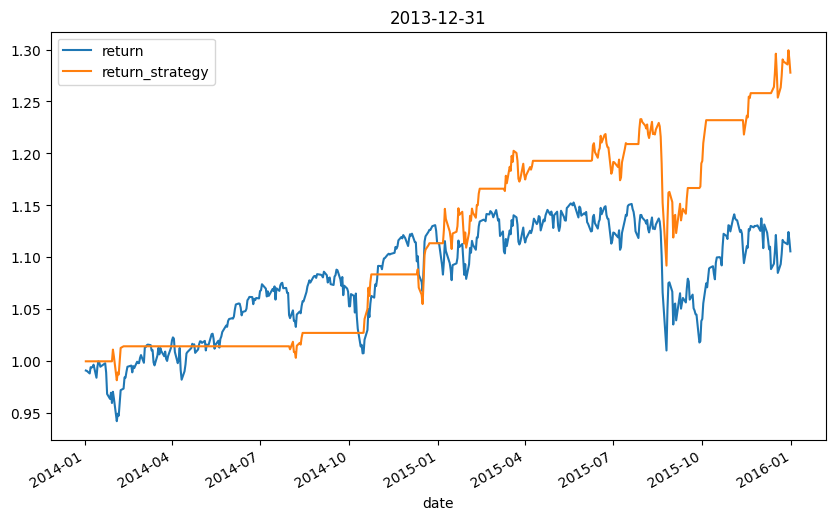

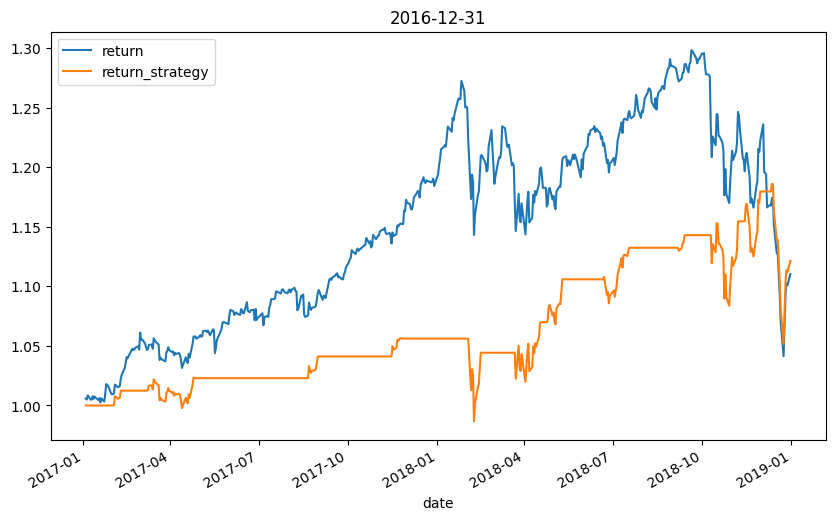

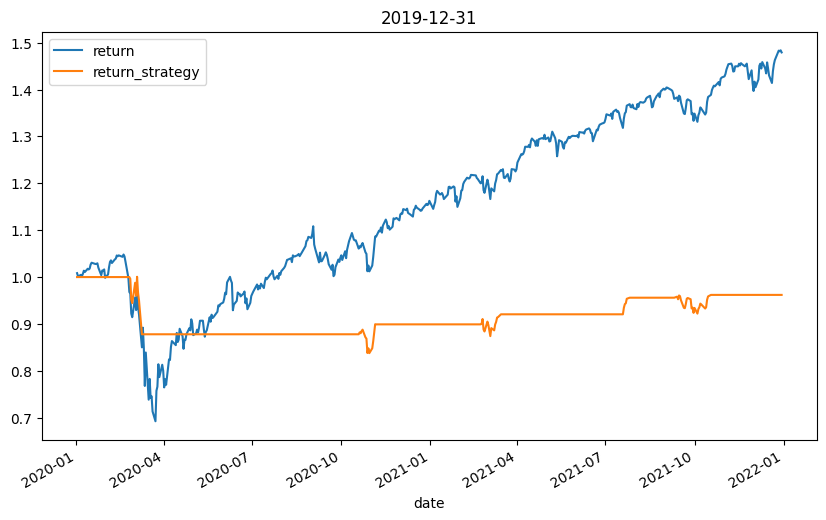

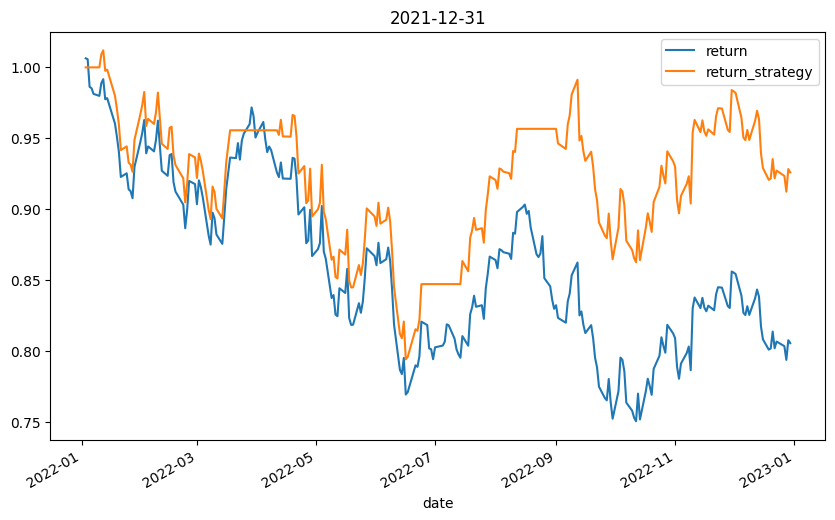

In [ ]:
window, up_threshold, down_threshold, up_std, down_std = 5, 80, 20, 0.5, 0.5 #GSPC
# window, up_threshold, down_threshold, up_std, down_std = 5, 70, 30, 0.5, 0.0 #YLGF
# window, up_threshold, down_threshold, up_std, down_std = 14, 80, 20, 0.0, 0.0 #GFLY
for launch_point in backtest_launch_points:
    output_backtest = RSI(window, up_threshold, down_threshold, up_std, down_std, data_train, launch_point, look_back_window, backtest_length, 0)
    # drop the added last row
    output_backtest = output_backtest.dropna()
    output_backtest[["return", f"return_strategy"]].cumsum().apply(np.exp).plot(figsize=(10, 6), title = launch_point)
    # output_backtest[["open_price"]].plot(figsize=(10, 6))
    # output_backtest[f"position_strategy"].plot(secondary_y = True, legend = "position")
    # output_backtest[["close"]].plot(secondary_y = True, legend = "close")

## Forecast

In [ ]:
window, up_threshold, down_threshold, up_std, down_std = 5, 80, 20, 0.5, 0.5 #GSPC
# window, up_threshold, down_threshold, up_std, down_std = 5, 70, 30, 0.5, 0.0 #YLGF
# window, up_threshold, down_threshold, up_std, down_std = 14, 80, 20, 0.0, 0.0 #GFLY
launch_point = "2023-01-01"
# launch_point = "2024-03-01" #^GSPC
# launch_point = "2024-03-06" #YLGF
# launch_point = "2024-02-25" #GFLY
output_test = RSI(window, up_threshold, down_threshold, up_std, down_std, data_test, launch_point, look_back_window, backtest_length, 0)
new_row = {
    "window": window,
    "up_threshold": up_threshold,
    "down_threshold": down_threshold,
    "up_std": up_std,
    "down_std": down_std,
    "launch_point": launch_point,
    "num_transaction_per_year": annual_num_transaction(output_test[f"position_strategy"]),
    "annual_return": annual_return(output_test[f"return_strategy"]),
    "annual_vol": annual_volatility(output_test[f"return_strategy"]),
    "cum_return": cum_return(output_test[f"return_strategy"]),
    "max_drawdown": max_drawdown(output_test[f"return_strategy"]),
    "information_ratio": information_ratio(output_test[f"return_strategy"], output_test["return"])
}

In [ ]:
new_row

{'window': 5,
 'up_threshold': 80,
 'down_threshold': 20,
 'up_std': 0.5,
 'down_std': 0.5,
 'launch_point': '2023-01-01',
 'num_transaction_per_year': 9.029315960912053,
 'annual_return': 0.10540257729832665,
 'annual_vol': 0.08164415096055086,
 'cum_return': nan,
 'max_drawdown': 0.0475889151390563,
 'information_ratio': -1.5531444492146436}

<Axes: >

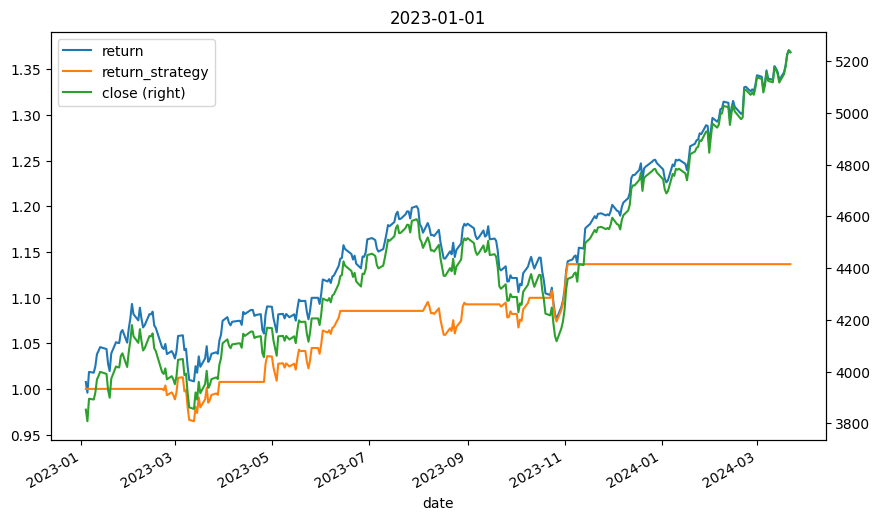

In [ ]:
output_test[["return", f"return_strategy"]].cumsum().apply(np.exp).plot(figsize=(10, 6), title = launch_point)
# output_test[["close", f"SMA_{short_term}", f"SMA_{long_term}"]].plot(figsize=(10, 6))
# output_test[f"position_strategy"].plot(secondary_y = True, legend = "position")
output_test["close"].plot(secondary_y = True, legend = "close")

In [ ]:
output_test.tail(10)

,Open,High,Low,Close,Adj Close,Volume,close,open,high,low,return,position_strategy,price_change,RS,RSI,RSI_std,return_strategy
date,,,,,,,,,,,,,,,,,
2024-03-12,5134.299805,5179.870117,5114.479980,5175.270020,5175.270020,4.080510e+09,5175.270020,5134.299805,5179.870117,5114.479980,0.011140,0.0,57.330078,3.451048,77.533380,13.649903,0.0
2024-03-13,5173.490234,5179.140137,5151.879883,5165.310059,5165.310059,4.282890e+09,5165.310059,5173.490234,5179.140137,5151.879883,-0.001926,0.0,-9.959961,2.226214,69.003914,14.294833,-0.0
2024-03-14,5175.140137,5176.850098,5123.299805,5150.479980,5150.479980,4.687970e+09,5150.479980,5175.140137,5176.850098,5123.299805,-0.002875,0.0,-14.830078,0.892853,47.169705,14.986683,-0.0
2024-03-15,5123.310059,5136.859863,5104.350098,5117.089844,5117.089844,7.753670e+09,5117.089844,5123.310059,5136.859863,5104.350098,-0.006504,0.0,-33.390137,0.896761,47.278540,14.772606,-0.0
2024-03-18,5154.770020,5175.600098,5145.470215,5149.419922,5149.419922,4.036220e+09,5149.419922,5154.770020,5175.600098,5145.470215,0.006298,0.0,32.330078,1.541077,60.646615,13.368126,0.0
2024-03-19,5139.089844,5180.310059,5131.589844,5178.509766,5178.509766,4.031760e+09,5178.509766,5139.089844,5180.310059,5131.589844,0.005633,0.0,29.089844,1.055685,51.354408,9.515482,0.0
2024-03-20,5181.689941,5226.189941,5171.549805,5224.620117,5224.620117,4.064850e+09,5224.620117,5181.689941,5226.189941,5171.549805,0.008865,0.0,46.110352,2.229983,69.040088,9.528709,0.0
2024-03-21,5253.430176,5261.100098,5240.660156,5241.529785,5241.529785,4.207730e+09,5241.529785,5253.430176,5261.100098,5240.660156,0.003231,0.0,16.909668,3.726847,78.844250,12.879873,0.0
2024-03-22,5242.479980,5246.089844,5229.870117,5234.180176,5234.180176,3.374700e+09,5234.180176,5242.479980,5246.089844,5229.870117,-0.001403,0.0,-7.349609,16.931504,94.423223,16.636309,-0.0
